## Workflow:

1. Load data
2. Split into X and y
3. Train-test split
4. Choose model
5. fit()
6. predict()
7. evaluate()

### 1. Load Dataset

In [3]:
import pandas as pd

data = {
    "area": [800, 900, 1000, 1100, 1200, 1300],
    "price": [20, 22, 25, 27, 30, 32]
}

df = pd.DataFrame(data)
display(df)

,area,price
0,800,20
1,900,22
2,1000,25
3,1100,27
4,1200,30
5,1300,32


### 2. Split - Features (X) and Target (y)

| 1D | 2D |
|----|----|
|[800, 900, 1000] | [ [800], [900], [1000] ] |
|for y | for X |



In [11]:
X = df[["area"]]   # MUST be 2D (just encase in another bracket)
y = df["price"]    # 1D

Why X is capital and y is small:

Historical + math reason
- Capital letters → matrices (2D)
- Small letters → vectors (1D)

### 3. Train–Test Split

- test_size=0.2 → 20% data for testing
- random_state → seed value to get the same train-test split everytime for easy debugging

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(X_train, X_test, y_train, y_test)


,area
5,1300
2,1000
4,1200
3,1100


,area
0,800
1,900


5    32
2    25
4    30
3    27
Name: price, dtype: int64

0    20
1    22
Name: price, dtype: int64

### 4. Choose a Model

Linear Regression: The model finds the best straight line that minimizes error.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


### 5. fit()

Choose the best fitting line for the model

| Parameter            | Meaning (simple)                 |
| -------------------- | -------------------------------- |
| `fit_intercept=True` | Model learns `c` in `y = mx + c` |
| `copy_X=True`        | Keeps original X unchanged       |
| `tol=1e-06`          | Precision threshold for solution |
| `n_jobs=None`        | CPU cores used                   |
| `positive=False`     | Coefficients can be negative     |


In [14]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 6. Make Predictions (predict())

X is the data and y is the target

predict() always uses unseen data

In [19]:
y_pred = model.predict(X_test)
print(y_pred)

[20.1 22.5]


### 7. Evaluate the Model (evaluate()) 

Lower error = better model

<pre>error = actual − predicted

Find error for each point
20 − 22 = -2
25 − 24 = 1
30 − 29 = 1

Square the errors
(-2)² = 4
(1)²  = 1
(1)²  = 1


Take the mean (average)
MSE = (4 + 1 + 1) / 3 = 2</pre>

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.13000000000000014


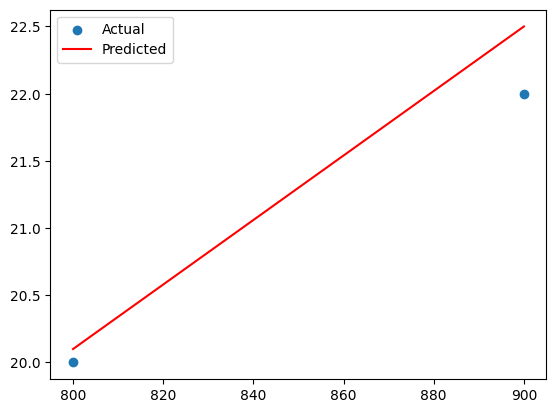

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="Actual")     # Data points (scatter)
plt.plot(X_test, y_pred, color="red", label="Predicted")    #Linear Regression line (line plot)
plt.legend()
plt.show()
